<a href="https://colab.research.google.com/github/asrianda/jurnal/blob/main/XGBoost_Modifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('ecommerce_user_behavior_8000.csv')
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


👉 Numerical → mean
👉 Categorical → mode **bold text**

In [ ]:
# Pisahkan tipe data
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Isi missing numerical dengan mean
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Isi missing categorical dengan mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_800/2157858227.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_800/2157858227.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
#df.isnull().sum()
#df.shape
df['purchase'].value_counts()

,count
purchase,
1.000000,7827
0.998342,160
0.000000,13


**Encoding (jika ada categorical)**

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

**Pipeline Awal**

In [ ]:
df['returning_user'].value_counts()

,count
returning_user,
1.000000,3994
0.000000,3846
0.509439,160


**Program yang Benar XGBoost Modifikasi**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET MULTI-CLASS
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

X = df.drop(columns=['target', 'purchase']).values
y = df['target'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, m = X_train.shape
num_class = 3

# ===============================
# 4. INITIALIZATION
# ===============================
y_hat = np.zeros((n, num_class))
trees = []   # 🔥 simpan model

K = 30
eta = 0.1
lambda_ = 1
gamma = 0.0

# ===============================
# 5. SOFTMAX
# ===============================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ===============================
# 6. TRAINING
# ===============================
for t in range(K):

    probs = softmax(y_hat)

    # gradient & hessian
    g = probs.copy()
    h = probs * (1 - probs)

    for i in range(n):
        g[i, y_train[i]] -= 1

    best_gain_log = -np.inf
    best_feature = None
    best_threshold = None
    best_w_L = None
    best_w_R = None

    for feature in range(m):

        thresholds = np.percentile(X_train[:, feature], [20,40,60,80])

        for threshold in thresholds:

            left = X_train[:, feature] <= threshold
            right = ~left

            if np.sum(left) < 10 or np.sum(right) < 10:
                continue

            # ===============================
            # MULTI-CLASS AGGREGATION
            # ===============================
            G_L = np.sum(g[left], axis=0)
            H_L = np.sum(h[left], axis=0)

            G_R = np.sum(g[right], axis=0)
            H_R = np.sum(h[right], axis=0)

            G = G_L + G_R
            H = H_L + H_R

            # ===============================
            # 🔥 Eq. (9) STABIL
            # ===============================
            alpha = 0.05
            G_L_mod = (2 * G_L) / (1 + alpha * G_L**2)
            G_R_mod = (2 * G_R) / (1 + alpha * G_R**2)
            G_mod   = (2 * G)   / (1 + alpha * G**2)

            # ===============================
            # GAIN MULTI-CLASS
            # ===============================
            def score(G, H):
                return np.sum((G**2) / (H + lambda_))

            gain = 0.5 * (
                score(G_L_mod, H_L) +
                score(G_R_mod, H_R) -
                score(G_mod, H)
            ) - gamma

            gain_log = np.log(1 + max(gain, 1e-10))

            if gain_log > best_gain_log:
                best_gain_log = gain_log
                best_feature = feature
                best_threshold = threshold

                # simpan weight
                best_w_L = - G_L / (H_L + lambda_)
                best_w_R = - G_R / (H_R + lambda_)

    if best_feature is None:
        print("Early stop")
        break

    # ===============================
    # SIMPAN TREE
    # ===============================
    trees.append((best_feature, best_threshold, best_w_L, best_w_R))

    # ===============================
    # UPDATE MODEL
    # ===============================
    left = X_train[:, best_feature] <= best_threshold
    right = ~left

    y_hat[left] += eta * best_w_L
    y_hat[right] += eta * best_w_R

    print(f"Iteration {t+1}, Log-Gain: {best_gain_log:.5f}")

# ===============================
# 7. PREDICTION (FIX UTAMA)
# ===============================
def predict(X):
    y_pred = np.zeros((len(X), num_class))

    for (feature, threshold, w_L, w_R) in trees:
        left = X[:, feature] <= threshold
        right = ~left

        y_pred[left] += eta * w_L
        y_pred[right] += eta * w_R

    probs = softmax(y_pred)
    return np.argmax(probs, axis=1)

# ===============================
# 8. EVALUATION
# ===============================
y_pred = predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Iteration 1, Log-Gain: 0.32596
Iteration 2, Log-Gain: 0.27084
Iteration 3, Log-Gain: 0.21990
Iteration 4, Log-Gain: 0.17501
Iteration 5, Log-Gain: 0.13693
Iteration 6, Log-Gain: 0.10561
Iteration 7, Log-Gain: 0.08822
Iteration 8, Log-Gain: 0.09675
Iteration 9, Log-Gain: 0.10323
Iteration 10, Log-Gain: 0.10727
Iteration 11, Log-Gain: 0.10846
Iteration 12, Log-Gain: 0.10649
Iteration 13, Log-Gain: 0.10129
Iteration 14, Log-Gain: 0.09315
Iteration 15, Log-Gain: 0.08277
Iteration 16, Log-Gain: 0.08098
Iteration 17, Log-Gain: 0.09285
Iteration 18, Log-Gain: 0.10253
Iteration 19, Log-Gain: 0.10896
Iteration 20, Log-Gain: 0.11149
Iteration 21, Log-Gain: 0.11002
Iteration 22, Log-Gain: 0.10491
Iteration 23, Log-Gain: 0.09679
Iteration 24, Log-Gain: 0.08646
Iteration 25, Log-Gain: 0.08390
Iteration 26, Log-Gain: 0.07747
Iteration 27, Log-Gain: 0.07492
Iteration 28, Log-Gain: 0.07126
Iteration 29, Log-Gain: 0.06915
Iteration 30, Log-Gain: 0.06523

Confusion Matrix:
[[335 129  70]
 [330 110  93]


**XGBoost Modifikasi**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

X = df.drop(columns=['target', 'purchase']).values
y = df['target'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, m = X_train.shape
num_class = 3

# ===============================
# 4. PARAMETER
# ===============================
K = 80
eta = 0.2
lambda_ = 1
gamma = 0.0
alpha = 0.005   # Eq.9 stabil

# ===============================
# 5. INIT
# ===============================
y_hat = np.zeros((n, num_class))
trees = []

# ===============================
# 6. SOFTMAX
# ===============================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ===============================
# 7. SCORE FUNCTION
# ===============================
def score(G, H):
    return np.sum((G**2) / (H + lambda_))

# ===============================
# 8. TRAINING (DEPTH-2 TREE)
# ===============================
for t in range(K):

    probs = softmax(y_hat)

    g = probs.copy()
    h = probs * (1 - probs)

    for i in range(n):
        g[i, y_train[i]] -= 1

    best_gain = -np.inf
    best_tree = None

    # ===========================
    # ROOT SPLIT
    # ===========================
    for f1 in range(m):

        thresholds1 = np.percentile(X_train[:, f1], [20,40,60,80])

        for t1 in thresholds1:

            left1 = X_train[:, f1] <= t1
            right1 = ~left1

            if np.sum(left1) < 20 or np.sum(right1) < 20:
                continue

            # ===========================
            # SECOND SPLIT (LEFT)
            # ===========================
            for f2 in range(m):

                thresholds2 = np.percentile(X_train[left1][:, f2], [30,60])

                for t2 in thresholds2:

                    LL = left1 & (X_train[:, f2] <= t2)
                    LR = left1 & (X_train[:, f2] > t2)

                    if np.sum(LL) < 10 or np.sum(LR) < 10:
                        continue

                    # ===========================
                    # SECOND SPLIT (RIGHT)
                    # ===========================
                    for f3 in range(m):

                        thresholds3 = np.percentile(X_train[right1][:, f3], [30,60])

                        for t3 in thresholds3:

                            RL = right1 & (X_train[:, f3] <= t3)
                            RR = right1 & (X_train[:, f3] > t3)

                            if np.sum(RL) < 10 or np.sum(RR) < 10:
                                continue

                            # ===========================
                            # HITUNG G,H
                            # ===========================
                            nodes = [LL, LR, RL, RR]
                            Gs = [np.sum(g[node], axis=0) for node in nodes]
                            Hs = [np.sum(h[node], axis=0) for node in nodes]

                            G_total = sum(Gs)
                            H_total = sum(Hs)

                            # ===========================
                            # Eq. (9)
                            # ===========================
                            Gs_mod = [(2 * G)/(1 + alpha * G**2) for G in Gs]
                            G_total_mod = (2 * G_total)/(1 + alpha * G_total**2)

                            gain = 0.5 * (
                                sum(score(Gs_mod[i], Hs[i]) for i in range(4)) -
                                score(G_total_mod, H_total)
                            )

                            gain_log = np.log(1 + max(gain, 1e-12))

                            if gain_log > best_gain:
                                best_gain = gain_log
                                best_tree = (f1, t1, f2, t2, f3, t3, Gs, Hs)

    if best_tree is None:
        print("Early stop")
        break

    f1, t1, f2, t2, f3, t3, Gs, Hs = best_tree

    # ===========================
    # HITUNG WEIGHT
    # ===========================
    weights = [ -Gs[i]/(Hs[i]+lambda_) for i in range(4) ]

    trees.append((f1, t1, f2, t2, f3, t3, weights))

    # ===========================
    # UPDATE MODEL
    # ===========================
    for i in range(n):

        if X_train[i, f1] <= t1:
            if X_train[i, f2] <= t2:
                y_hat[i] += eta * weights[0]
            else:
                y_hat[i] += eta * weights[1]
        else:
            if X_train[i, f3] <= t3:
                y_hat[i] += eta * weights[2]
            else:
                y_hat[i] += eta * weights[3]

    print(f"Iter {t+1}, Gain: {best_gain:.5f}")

# ===============================
# 9. PREDICTION
# ===============================
def predict(X):
    y_pred = np.zeros((len(X), num_class))

    for (f1, t1, f2, t2, f3, t3, weights) in trees:
        for i in range(len(X)):
            if X[i, f1] <= t1:
                if X[i, f2] <= t2:
                    y_pred[i] += eta * weights[0]
                else:
                    y_pred[i] += eta * weights[1]
            else:
                if X[i, f3] <= t3:
                    y_pred[i] += eta * weights[2]
                else:
                    y_pred[i] += eta * weights[3]

    probs = softmax(y_pred)
    return np.argmax(probs, axis=1)

# ===============================
# 10. EVALUATION
# ===============================
y_pred = predict(X_test)

print("\n===== DEPTH-2 MODIFIED XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1:", f1_score(y_test, y_pred, average='macro'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Iter 1, Gain: 3.89678
Iter 2, Gain: 3.87489
Iter 3, Gain: 3.80885
Iter 4, Gain: 3.79887
Iter 5, Gain: 3.75114
Iter 6, Gain: 3.68504
Iter 7, Gain: 3.64234
Iter 8, Gain: 3.52321
Iter 9, Gain: 3.44067
Iter 10, Gain: 3.27929
Iter 11, Gain: 3.16404
Iter 12, Gain: 2.98136
Iter 13, Gain: 2.88933
Iter 14, Gain: 2.86499
Iter 15, Gain: 2.73898
Iter 16, Gain: 3.00533
Iter 17, Gain: 3.23342
Iter 18, Gain: 3.33368
Iter 19, Gain: 3.40946
Iter 20, Gain: 3.64936
Iter 21, Gain: 3.80536
Iter 22, Gain: 3.81337
Iter 23, Gain: 3.68147
Iter 24, Gain: 3.45094
Iter 25, Gain: 3.16458
Iter 26, Gain: 3.09172
Iter 27, Gain: 3.02902
Iter 28, Gain: 2.90904
Iter 29, Gain: 2.76057
Iter 30, Gain: 2.84639
Iter 31, Gain: 2.93952
Iter 32, Gain: 2.99507
Iter 33, Gain: 3.06527
Iter 34, Gain: 3.06183
Iter 35, Gain: 3.08078
Iter 36, Gain: 3.04019
Iter 37, Gain: 2.96182
Iter 38, Gain: 2.83376
Iter 39, Gain: 2.76282
Iter 40, Gain: 2.98483
Iter 41, Gain: 3.16169
Iter 42, Gain: 3.23228
Iter 43, Gain: 3.25340
Iter 44, Gain: 3.426

**XGBoost Modifikasi + Laporan Klasifikasi**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

X = df.drop(columns=['target', 'purchase']).values
y = df['target'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, m = X_train.shape
num_class = 3

# ===============================
# 4. PARAMETER
# ===============================
K = 80
eta = 0.2
lambda_ = 1
gamma = 0.0
alpha = 0.005

# ===============================
# 5. INIT
# ===============================
y_hat = np.zeros((n, num_class))
trees = []

# ===============================
# 6. SOFTMAX
# ===============================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ===============================
# 7. SCORE FUNCTION
# ===============================
def score(G, H):
    return np.sum((G**2) / (H + lambda_))

# ===============================
# 8. TRAINING (DEPTH-2 TREE)
# ===============================
for t in range(K):

    probs = softmax(y_hat)
    g = probs.copy()
    h = probs * (1 - probs)

    for i in range(n):
        g[i, y_train[i]] -= 1

    best_gain = -np.inf
    best_tree = None

    for f1 in range(m):
        thresholds1 = np.percentile(X_train[:, f1], [20,40,60,80])

        for t1 in thresholds1:
            left1 = X_train[:, f1] <= t1
            right1 = ~left1

            if np.sum(left1) < 20 or np.sum(right1) < 20:
                continue

            for f2 in range(m):
                thresholds2 = np.percentile(X_train[left1][:, f2], [30,60])

                for t2 in thresholds2:
                    LL = left1 & (X_train[:, f2] <= t2)
                    LR = left1 & (X_train[:, f2] > t2)

                    if np.sum(LL) < 10 or np.sum(LR) < 10:
                        continue

                    for f3 in range(m):
                        thresholds3 = np.percentile(X_train[right1][:, f3], [30,60])

                        for t3 in thresholds3:
                            RL = right1 & (X_train[:, f3] <= t3)
                            RR = right1 & (X_train[:, f3] > t3)

                            if np.sum(RL) < 10 or np.sum(RR) < 10:
                                continue

                            nodes = [LL, LR, RL, RR]
                            Gs = [np.sum(g[node], axis=0) for node in nodes]
                            Hs = [np.sum(h[node], axis=0) for node in nodes]

                            G_total = sum(Gs)
                            H_total = sum(Hs)

                            # Eq. (9)
                            Gs_mod = [(2 * G)/(1 + alpha * G**2) for G in Gs]
                            G_total_mod = (2 * G_total)/(1 + alpha * G_total**2)

                            gain = 0.5 * (
                                sum(score(Gs_mod[i], Hs[i]) for i in range(4)) -
                                score(G_total_mod, H_total)
                            )

                            gain_log = np.log(1 + max(gain, 1e-12))

                            if gain_log > best_gain:
                                best_gain = gain_log
                                best_tree = (f1, t1, f2, t2, f3, t3, Gs, Hs)

    if best_tree is None:
        print("Early stop")
        break

    f1, t1, f2, t2, f3, t3, Gs, Hs = best_tree

    weights = [ -Gs[i]/(Hs[i]+lambda_) for i in range(4) ]
    trees.append((f1, t1, f2, t2, f3, t3, weights))

    for i in range(n):
        if X_train[i, f1] <= t1:
            if X_train[i, f2] <= t2:
                y_hat[i] += eta * weights[0]
            else:
                y_hat[i] += eta * weights[1]
        else:
            if X_train[i, f3] <= t3:
                y_hat[i] += eta * weights[2]
            else:
                y_hat[i] += eta * weights[3]

    print(f"Iter {t+1}, Gain: {best_gain:.5f}")

# ===============================
# 9. PREDICTION
# ===============================
def predict(X):
    y_pred = np.zeros((len(X), num_class))

    for (f1, t1, f2, t2, f3, t3, weights) in trees:
        for i in range(len(X)):
            if X[i, f1] <= t1:
                if X[i, f2] <= t2:
                    y_pred[i] += eta * weights[0]
                else:
                    y_pred[i] += eta * weights[1]
            else:
                if X[i, f3] <= t3:
                    y_pred[i] += eta * weights[2]
                else:
                    y_pred[i] += eta * weights[3]

    probs = softmax(y_pred)
    return np.argmax(probs, axis=1)

# ===============================
# 10. EVALUATION (LENGKAP)
# ===============================
y_pred = predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

prec_weight = precision_score(y_test, y_pred, average='weighted')
rec_weight = recall_score(y_test, y_pred, average='weighted')
f1_weight = f1_score(y_test, y_pred, average='weighted')

print("\n===== DEPTH-2 MODIFIED XGBOOST =====")

print("\n--- Overall ---")
print(f"Accuracy            : {acc:.4f}")

print("\n--- Macro Average ---")
print(f"Precision (Macro)   : {prec_macro:.4f}")
print(f"Recall (Macro)      : {rec_macro:.4f}")
print(f"F1-score (Macro)    : {f1_macro:.4f}")

print("\n--- Weighted Average ---")
print(f"Precision (Weighted): {prec_weight:.4f}")
print(f"Recall (Weighted)   : {rec_weight:.4f}")
print(f"F1-score (Weighted) : {f1_weight:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Class 0", "Class 1", "Class 2"]
))

print("\nPrediction Distribution:")
print(pd.Series(y_pred).value_counts())

Iter 1, Gain: 3.89678
Iter 2, Gain: 3.87489
Iter 3, Gain: 3.80885
Iter 4, Gain: 3.79887
Iter 5, Gain: 3.75114
Iter 6, Gain: 3.68504
Iter 7, Gain: 3.64234
Iter 8, Gain: 3.52321
Iter 9, Gain: 3.44067
Iter 10, Gain: 3.27929
Iter 11, Gain: 3.16404
Iter 12, Gain: 2.98136
Iter 13, Gain: 2.88933
Iter 14, Gain: 2.86499
Iter 15, Gain: 2.73898
Iter 16, Gain: 3.00533
Iter 17, Gain: 3.23342
Iter 18, Gain: 3.33368
Iter 19, Gain: 3.40946
Iter 20, Gain: 3.64936
Iter 21, Gain: 3.80536
Iter 22, Gain: 3.81337
Iter 23, Gain: 3.68147
Iter 24, Gain: 3.45094
Iter 25, Gain: 3.16458
Iter 26, Gain: 3.09172
Iter 27, Gain: 3.02902
Iter 28, Gain: 2.90904
Iter 29, Gain: 2.76057
Iter 30, Gain: 2.84639
Iter 31, Gain: 2.93952
Iter 32, Gain: 2.99507
Iter 33, Gain: 3.06527
Iter 34, Gain: 3.06183
Iter 35, Gain: 3.08078
Iter 36, Gain: 3.04019
Iter 37, Gain: 2.96182
Iter 38, Gain: 2.83376
Iter 39, Gain: 2.76282
Iter 40, Gain: 2.98483
Iter 41, Gain: 3.16169
Iter 42, Gain: 3.23228
Iter 43, Gain: 3.25340
Iter 44, Gain: 3.426

**Menambah Loss Iterasi pada XGBoost Modifikasi**

Iter   1 | Loss: 0.982297 | Gain: 3.865324
Iter   2 | Loss: 0.926977 | Gain: 3.736723
Iter   3 | Loss: 0.925716 | Gain: 3.628695
Iter   4 | Loss: 0.924560 | Gain: 3.531530
Iter   5 | Loss: 0.838312 | Gain: 3.415727
Iter   6 | Loss: 0.837557 | Gain: 3.282043
Iter   7 | Loss: 0.787855 | Gain: 3.243631
Iter   8 | Loss: 0.773583 | Gain: 3.170083
Iter   9 | Loss: 0.765198 | Gain: 3.221590
Iter  10 | Loss: 0.760279 | Gain: 3.171562
Iter  11 | Loss: 0.757408 | Gain: 3.214057
Iter  12 | Loss: 0.755570 | Gain: 3.376393
Iter  13 | Loss: 0.754450 | Gain: 3.418935
Iter  14 | Loss: 0.753679 | Gain: 3.344500
Iter  15 | Loss: 0.753188 | Gain: 3.197313
Iter  16 | Loss: 0.752783 | Gain: 3.052101
Iter  17 | Loss: 0.752423 | Gain: 3.041462
Iter  18 | Loss: 0.752058 | Gain: 2.958955
Iter  19 | Loss: 0.749777 | Gain: 2.887302
Iter  20 | Loss: 0.748482 | Gain: 2.997734
Iter  21 | Loss: 0.747697 | Gain: 2.990826
Iter  22 | Loss: 0.747203 | Gain: 2.896110
Iter  23 | Loss: 0.745227 | Gain: 2.752631
Iter  24 | 

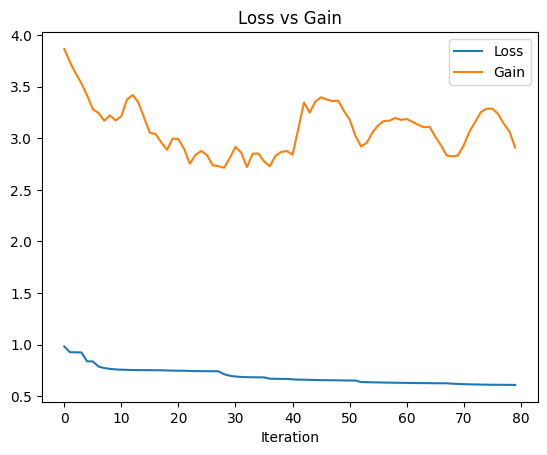

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

# ⚠️ (optional fix leakage)
X = df.drop(columns=['target', 'purchase', 'avg_session_time']).values
y = df['target'].astype(int).values

# ===============================
# 4. SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, m = X_train.shape
num_class = 3

# ===============================
# 5. PARAMETER
# ===============================
K = 80
eta = 0.2
lambda_ = 1
alpha = 0.005

# ===============================
# 6. INIT
# ===============================
y_hat = np.zeros((n, num_class))
trees = []

loss_history = []
gain_history = []

# ===============================
# 7. FUNCTIONS
# ===============================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    probs = softmax(y_pred)
    loss = -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + 1e-12))
    return loss

def score(G, H):
    return np.sum((G**2) / (H + lambda_))

# ===============================
# 8. TRAINING
# ===============================
for t in range(K):

    probs = softmax(y_hat)
    g = probs.copy()
    h = probs * (1 - probs)

    for i in range(n):
        g[i, y_train[i]] -= 1

    best_gain = -np.inf
    best_tree = None

    for f1 in range(m):
        thresholds1 = np.percentile(X_train[:, f1], [20,40,60,80])

        for t1 in thresholds1:
            left1 = X_train[:, f1] <= t1
            right1 = ~left1

            if np.sum(left1) < 20 or np.sum(right1) < 20:
                continue

            for f2 in range(m):
                thresholds2 = np.percentile(X_train[left1][:, f2], [30,60])

                for t2 in thresholds2:
                    LL = left1 & (X_train[:, f2] <= t2)
                    LR = left1 & (X_train[:, f2] > t2)

                    if np.sum(LL) < 10 or np.sum(LR) < 10:
                        continue

                    for f3 in range(m):
                        thresholds3 = np.percentile(X_train[right1][:, f3], [30,60])

                        for t3 in thresholds3:
                            RL = right1 & (X_train[:, f3] <= t3)
                            RR = right1 & (X_train[:, f3] > t3)

                            if np.sum(RL) < 10 or np.sum(RR) < 10:
                                continue

                            nodes = [LL, LR, RL, RR]
                            Gs = [np.sum(g[node], axis=0) for node in nodes]
                            Hs = [np.sum(h[node], axis=0) for node in nodes]

                            G_total = sum(Gs)
                            H_total = sum(Hs)

                            Gs_mod = [(2 * G)/(1 + alpha * G**2) for G in Gs]
                            G_total_mod = (2 * G_total)/(1 + alpha * G_total**2)

                            gain = 0.5 * (
                                sum(score(Gs_mod[i], Hs[i]) for i in range(4)) -
                                score(G_total_mod, H_total)
                            )

                            gain_log = np.log(1 + max(gain, 1e-12))

                            if gain_log > best_gain:
                                best_gain = gain_log
                                best_tree = (f1, t1, f2, t2, f3, t3, Gs, Hs)

    if best_tree is None:
        print("Early stop")
        break

    f1, t1, f2, t2, f3, t3, Gs, Hs = best_tree

    weights = [-Gs[i]/(Hs[i]+lambda_) for i in range(4)]
    trees.append((f1, t1, f2, t2, f3, t3, weights))

    for i in range(n):
        if X_train[i, f1] <= t1:
            if X_train[i, f2] <= t2:
                y_hat[i] += eta * weights[0]
            else:
                y_hat[i] += eta * weights[1]
        else:
            if X_train[i, f3] <= t3:
                y_hat[i] += eta * weights[2]
            else:
                y_hat[i] += eta * weights[3]

    # ===============================
    # TRACK LOSS & GAIN
    # ===============================
    current_loss = compute_loss(y_train, y_hat)
    loss_history.append(current_loss)
    gain_history.append(best_gain)

    print(f"Iter {t+1:3d} | Loss: {current_loss:.6f} | Gain: {best_gain:.6f}")

# ===============================
# 9. PREDICTION
# ===============================
def predict(X):
    y_pred = np.zeros((len(X), num_class))

    for (f1, t1, f2, t2, f3, t3, weights) in trees:
        for i in range(len(X)):
            if X[i, f1] <= t1:
                if X[i, f2] <= t2:
                    y_pred[i] += eta * weights[0]
                else:
                    y_pred[i] += eta * weights[1]
            else:
                if X[i, f3] <= t3:
                    y_pred[i] += eta * weights[2]
                else:
                    y_pred[i] += eta * weights[3]

    return np.argmax(softmax(y_pred), axis=1)

# ===============================
# 10. EVALUATION
# ===============================
y_pred = predict(X_test)

print("\n===== FINAL MODEL =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1:", f1_score(y_test, y_pred, average='macro'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 11. PLOT LOSS & GAIN
# ===============================
plt.figure()
plt.plot(loss_history, label="Loss")
plt.plot(gain_history, label="Gain")
plt.xlabel("Iteration")
plt.title("Loss vs Gain")
plt.legend()
plt.show()

**XGBoost Modifikasi Split Data 70:30**

Iter   1 | Loss: 0.982395 | Gain: 3.915753
Iter   2 | Loss: 0.980486 | Gain: 3.726638
Iter   3 | Loss: 0.979240 | Gain: 3.578212
Iter   4 | Loss: 0.978007 | Gain: 3.560382
Iter   5 | Loss: 0.977258 | Gain: 3.340327
Iter   6 | Loss: 0.871814 | Gain: 3.217856
Iter   7 | Loss: 0.871201 | Gain: 3.118367
Iter   8 | Loss: 0.812552 | Gain: 2.952860
Iter   9 | Loss: 0.786085 | Gain: 3.026793
Iter  10 | Loss: 0.770692 | Gain: 3.179325
Iter  11 | Loss: 0.761628 | Gain: 3.247243
Iter  12 | Loss: 0.756292 | Gain: 3.226725
Iter  13 | Loss: 0.753149 | Gain: 3.315950
Iter  14 | Loss: 0.751152 | Gain: 3.441921
Iter  15 | Loss: 0.749926 | Gain: 3.453560
Iter  16 | Loss: 0.749065 | Gain: 3.354714
Iter  17 | Loss: 0.748505 | Gain: 3.206910
Iter  18 | Loss: 0.747991 | Gain: 3.039991
Iter  19 | Loss: 0.747494 | Gain: 2.920342
Iter  20 | Loss: 0.745075 | Gain: 2.907516
Iter  21 | Loss: 0.743611 | Gain: 2.983078
Iter  22 | Loss: 0.742700 | Gain: 2.971211
Iter  23 | Loss: 0.742138 | Gain: 2.886551
Iter  24 | 

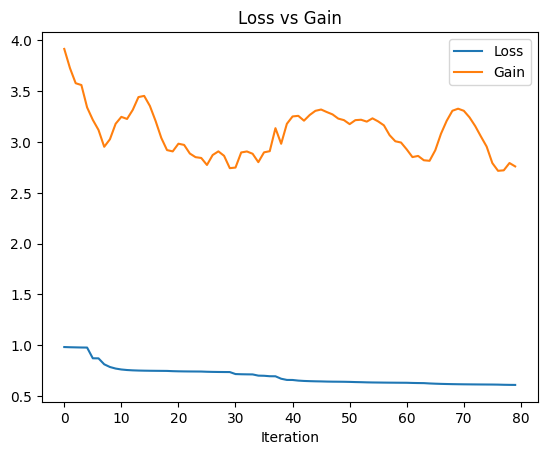

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

# ⚠️ (optional fix leakage)
X = df.drop(columns=['target', 'purchase', 'avg_session_time']).values
y = df['target'].astype(int).values

# ===============================
# 4. SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n, m = X_train.shape
num_class = 3

# ===============================
# 5. PARAMETER
# ===============================
K = 80
eta = 0.2
lambda_ = 1
alpha = 0.005

# ===============================
# 6. INIT
# ===============================
y_hat = np.zeros((n, num_class))
trees = []

loss_history = []
gain_history = []

# ===============================
# 7. FUNCTIONS
# ===============================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    probs = softmax(y_pred)
    loss = -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + 1e-12))
    return loss

def score(G, H):
    return np.sum((G**2) / (H + lambda_))

# ===============================
# 8. TRAINING
# ===============================
for t in range(K):

    probs = softmax(y_hat)
    g = probs.copy()
    h = probs * (1 - probs)

    for i in range(n):
        g[i, y_train[i]] -= 1

    best_gain = -np.inf
    best_tree = None

    for f1 in range(m):
        thresholds1 = np.percentile(X_train[:, f1], [20,40,60,80])

        for t1 in thresholds1:
            left1 = X_train[:, f1] <= t1
            right1 = ~left1

            if np.sum(left1) < 20 or np.sum(right1) < 20:
                continue

            for f2 in range(m):
                thresholds2 = np.percentile(X_train[left1][:, f2], [30,60])

                for t2 in thresholds2:
                    LL = left1 & (X_train[:, f2] <= t2)
                    LR = left1 & (X_train[:, f2] > t2)

                    if np.sum(LL) < 10 or np.sum(LR) < 10:
                        continue

                    for f3 in range(m):
                        thresholds3 = np.percentile(X_train[right1][:, f3], [30,60])

                        for t3 in thresholds3:
                            RL = right1 & (X_train[:, f3] <= t3)
                            RR = right1 & (X_train[:, f3] > t3)

                            if np.sum(RL) < 10 or np.sum(RR) < 10:
                                continue

                            nodes = [LL, LR, RL, RR]
                            Gs = [np.sum(g[node], axis=0) for node in nodes]
                            Hs = [np.sum(h[node], axis=0) for node in nodes]

                            G_total = sum(Gs)
                            H_total = sum(Hs)

                            Gs_mod = [(2 * G)/(1 + alpha * G**2) for G in Gs]
                            G_total_mod = (2 * G_total)/(1 + alpha * G_total**2)

                            gain = 0.5 * (
                                sum(score(Gs_mod[i], Hs[i]) for i in range(4)) -
                                score(G_total_mod, H_total)
                            )

                            gain_log = np.log(1 + max(gain, 1e-12))

                            if gain_log > best_gain:
                                best_gain = gain_log
                                best_tree = (f1, t1, f2, t2, f3, t3, Gs, Hs)

    if best_tree is None:
        print("Early stop")
        break

    f1, t1, f2, t2, f3, t3, Gs, Hs = best_tree

    weights = [-Gs[i]/(Hs[i]+lambda_) for i in range(4)]
    trees.append((f1, t1, f2, t2, f3, t3, weights))

    for i in range(n):
        if X_train[i, f1] <= t1:
            if X_train[i, f2] <= t2:
                y_hat[i] += eta * weights[0]
            else:
                y_hat[i] += eta * weights[1]
        else:
            if X_train[i, f3] <= t3:
                y_hat[i] += eta * weights[2]
            else:
                y_hat[i] += eta * weights[3]

    # ===============================
    # TRACK LOSS & GAIN
    # ===============================
    current_loss = compute_loss(y_train, y_hat)
    loss_history.append(current_loss)
    gain_history.append(best_gain)

    print(f"Iter {t+1:3d} | Loss: {current_loss:.6f} | Gain: {best_gain:.6f}")

# ===============================
# 9. PREDICTION
# ===============================
def predict(X):
    y_pred = np.zeros((len(X), num_class))

    for (f1, t1, f2, t2, f3, t3, weights) in trees:
        for i in range(len(X)):
            if X[i, f1] <= t1:
                if X[i, f2] <= t2:
                    y_pred[i] += eta * weights[0]
                else:
                    y_pred[i] += eta * weights[1]
            else:
                if X[i, f3] <= t3:
                    y_pred[i] += eta * weights[2]
                else:
                    y_pred[i] += eta * weights[3]

    return np.argmax(softmax(y_pred), axis=1)

# ===============================
# 10. EVALUATION
# ===============================
y_pred = predict(X_test)

print("\n===== FINAL MODEL =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1:", f1_score(y_test, y_pred, average='macro'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 11. PLOT LOSS & GAIN
# ===============================
plt.figure()
plt.plot(loss_history, label="Loss")
plt.plot(gain_history, label="Gain")
plt.xlabel("Iteration")
plt.title("Loss vs Gain")
plt.legend()
plt.show()

**Grafik dan disimpan**

In [ ]:
# Combine loss and gain into one plot and save

import matplotlib.pyplot as plt

# Data
loss = [
0.982395,0.980486,0.979240,0.978007,0.977258,0.871814,0.871201,0.812552,0.786085,0.770692,
0.761628,0.756292,0.753149,0.751152,0.749926,0.749065,0.748505,0.747991,0.747494,0.745075,
0.743611,0.742700,0.742138,0.741736,0.741369,0.739222,0.737950,0.737131,0.736594,0.736219,
0.716618,0.714786,0.713754,0.713048,0.701205,0.699768,0.695294,0.694715,0.670567,0.658867,
0.658358,0.652214,0.648824,0.646787,0.645268,0.644222,0.642684,0.641788,0.641294,0.640696,
0.639539,0.637760,0.636612,0.634978,0.633902,0.633252,0.632532,0.632006,0.631595,0.631155,
0.630837,0.629165,0.628118,0.627434,0.624174,0.621812,0.619993,0.618594,0.617420,0.616511,
0.615760,0.615163,0.614607,0.614158,0.613739,0.613420,0.612636,0.611138,0.610252,0.609728
]

gain = [
3.915753,3.726638,3.578212,3.560382,3.340327,3.217856,3.118367,2.952860,3.026793,3.179325,
3.247243,3.226725,3.315950,3.441921,3.453560,3.354714,3.206910,3.039991,2.920342,2.907516,
2.983078,2.971211,2.886551,2.850836,2.842715,2.773974,2.871753,2.907839,2.863924,2.742491,
2.748421,2.897060,2.906909,2.884124,2.801619,2.898108,2.909617,3.135885,2.982468,3.178850,
3.251373,3.257356,3.209761,3.265643,3.306643,3.319473,3.294498,3.271505,3.230232,3.215136,
3.175749,3.214914,3.218902,3.200366,3.232648,3.202372,3.163811,3.066834,3.007131,2.994712,
2.926956,2.851534,2.862853,2.820231,2.814959,2.918473,3.080959,3.208323,3.307200,3.327624,
3.307069,3.242356,3.156428,3.053885,2.955015,2.792547,2.716394,2.721193,2.793038,2.759693
]

# Create combined plot
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(gain, label="Gain")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Loss and Gain per Iteration")
plt.legend()

# Save figure
file_path = "loss_gain_combined.png"
plt.savefig(file_path)
plt.close()

file_path

'loss_gain_combined.png'

**XGBoost Klasik**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import xgboost as xgb

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. CREATE TARGET (MULTI-CLASS)
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

# ===============================
# 4. REMOVE DATA LEAKAGE
# ===============================
X = df.drop(columns=['target', 'purchase', 'avg_session_time'])  # 🔥 FIX
y = df['target'].astype(int)

# ===============================
# 5. CHECK DISTRIBUTION
# ===============================
print("Class Distribution:")
print(y.value_counts())

# ===============================
# 6. SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 7. MODEL XGBOOST
# ===============================
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0,
    random_state=42,
    eval_metric='mlogloss'
)

# ===============================
# 8. TRAINING
# ===============================
model.fit(X_train, y_train)

# ===============================
# 9. PREDICTION
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 10. EVALUATION
# ===============================
print("\n===== XGBOOST (NO LEAKAGE) =====")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPrecision (Macro):")
print(precision_score(y_test, y_pred, average='macro'))

print("\nRecall (Macro):")
print(recall_score(y_test, y_pred, average='macro'))

print("\nF1-score (Macro):")
print(f1_score(y_test, y_pred, average='macro'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Class Distribution:
target
0    2670
2    2667
1    2663
Name: count, dtype: int64

===== XGBOOST (NO LEAKAGE) =====

Accuracy:
0.69

Precision (Macro):
0.6943882579014095

Recall (Macro):
0.6899478372484675

F1-score (Macro):
0.6900139767720371

Confusion Matrix:
[[413 112   9]
 [ 62 278 193]
 [  4 116 413]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.82       534
           1       0.55      0.52      0.54       533
           2       0.67      0.77      0.72       533

    accuracy                           0.69      1600
   macro avg       0.69      0.69      0.69      1600
weighted avg       0.69      0.69      0.69      1600



**XGBoosT + XGBoost SMOTE**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET + FIX DATA LEAKAGE
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

# 🔥 WAJIB: hapus sumber target dari fitur
X = df.drop(columns=['target', 'purchase', 'avg_session_time'])
y = df['target'].astype(int)

# ===============================
# 4. SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# FUNCTION EVALUASI
# ===============================
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    print("\nAccuracy:")
    print(accuracy_score(y_true, y_pred))

    print("\nPrecision (Macro):")
    print(precision_score(y_true, y_pred, average='macro'))

    print("\nRecall (Macro):")
    print(recall_score(y_true, y_pred, average='macro'))

    print("\nF1-score (Macro):")
    print(f1_score(y_true, y_pred, average='macro'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


# =========================================================
# MODEL 1: XGBOOST KLASIK
# =========================================================
model_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=42
)

model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

evaluate_model("XGBoost (Baseline)", y_test, y_pred_base)


# =========================================================
# MODEL 2: XGBOOST + SMOTE
# =========================================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_smote = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=42
)

model_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = model_smote.predict(X_test)

evaluate_model("XGBoost + SMOTE", y_test, y_pred_smote)


===== XGBoost (Baseline) =====

Accuracy:
0.69

Precision (Macro):
0.6943882579014095

Recall (Macro):
0.6899478372484675

F1-score (Macro):
0.6900139767720371

Confusion Matrix:
[[413 112   9]
 [ 62 278 193]
 [  4 116 413]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.82       534
           1       0.55      0.52      0.54       533
           2       0.67      0.77      0.72       533

    accuracy                           0.69      1600
   macro avg       0.69      0.69      0.69      1600
weighted avg       0.69      0.69      0.69      1600


===== XGBoost + SMOTE =====

Accuracy:
0.694375

Precision (Macro):
0.6983540781569704

Recall (Macro):
0.6943244021895708

F1-score (Macro):
0.6943965238399957

Confusion Matrix:
[[414 113   7]
 [ 63 282 188]
 [  4 114 415]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       534
         

**Iterasi GAIN**


=== Iteration Log: XGBoost ===
Iter   1 | Loss: 1.034205
Iter   2 | Loss: 0.979772 | Gain: 0.054434
Iter   3 | Loss: 0.933126 | Gain: 0.046645
Iter   4 | Loss: 0.892876 | Gain: 0.040250
Iter   5 | Loss: 0.857726 | Gain: 0.035150
Iter   6 | Loss: 0.826839 | Gain: 0.030887
Iter   7 | Loss: 0.799622 | Gain: 0.027217
Iter   8 | Loss: 0.775549 | Gain: 0.024073
Iter   9 | Loss: 0.754094 | Gain: 0.021455
Iter  10 | Loss: 0.735042 | Gain: 0.019051
Iter  11 | Loss: 0.718091 | Gain: 0.016951
Iter  12 | Loss: 0.702759 | Gain: 0.015332
Iter  13 | Loss: 0.689024 | Gain: 0.013735
Iter  14 | Loss: 0.676451 | Gain: 0.012573
Iter  15 | Loss: 0.665272 | Gain: 0.011179
Iter  16 | Loss: 0.655046 | Gain: 0.010226
Iter  17 | Loss: 0.645988 | Gain: 0.009057
Iter  18 | Loss: 0.637602 | Gain: 0.008387
Iter  19 | Loss: 0.630132 | Gain: 0.007470
Iter  20 | Loss: 0.623097 | Gain: 0.007035
Iter  21 | Loss: 0.616450 | Gain: 0.006647
Iter  22 | Loss: 0.610473 | Gain: 0.005977
Iter  23 | Loss: 0.604778 | Gain: 0.005

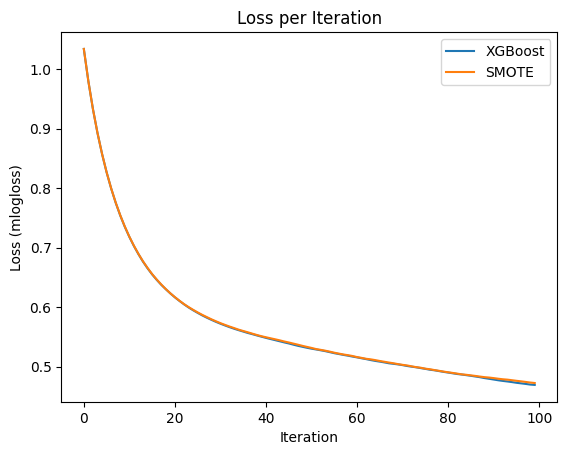

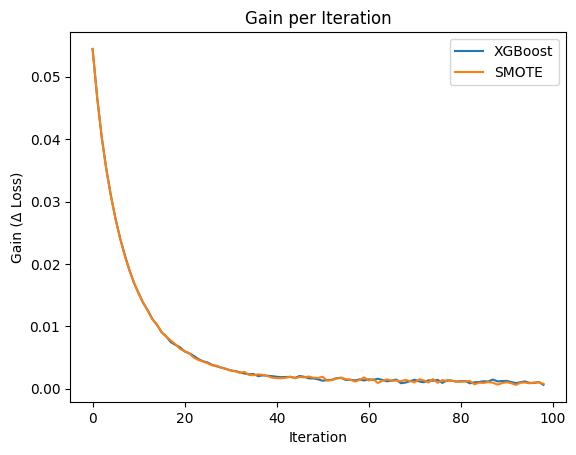

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET + FIX LEAKAGE
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

# 🔥 FIX DATA LEAKAGE
X = df.drop(columns=['target', 'purchase', 'avg_session_time'])
y = df['target'].astype(int)

# ===============================
# 4. SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# FUNCTION EVALUASI
# ===============================
def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")

    print("\nAccuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-score :", f1_score(y_true, y_pred, average='macro'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# =========================================================
# MODEL 1: XGBOOST
# =========================================================
model_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

model_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

# LOSS & GAIN
evals_result_base = model_base.evals_result()
loss_base = evals_result_base['validation_0']['mlogloss']
gain_base = -np.diff(loss_base)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost ===")
for i in range(len(loss_base)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f}")
    else:
        gain = loss_base[i-1] - loss_base[i]
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_base = model_base.predict(X_test)
evaluate("XGBoost", y_test, y_pred_base)

# =========================================================
# MODEL 2: XGBOOST + SMOTE
# =========================================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_smote = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

model_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_train_sm, y_train_sm)],
    verbose=False
)

evals_result_smote = model_smote.evals_result()
loss_smote = evals_result_smote['validation_0']['mlogloss']
gain_smote = -np.diff(loss_smote)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost + SMOTE ===")
for i in range(len(loss_smote)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f}")
    else:
        gain = loss_smote[i-1] - loss_smote[i]
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_smote = model_smote.predict(X_test)
evaluate("XGBoost + SMOTE", y_test, y_pred_smote)

# =========================================================
# PLOT LOSS
# =========================================================
plt.figure()
plt.plot(loss_base, label="XGBoost")
plt.plot(loss_smote, label="SMOTE")
plt.xlabel("Iteration")
plt.ylabel("Loss (mlogloss)")
plt.title("Loss per Iteration")
plt.legend()
plt.show()

# =========================================================
# PLOT GAIN
# =========================================================
plt.figure()
plt.plot(gain_base, label="XGBoost")
plt.plot(gain_smote, label="SMOTE")
plt.xlabel("Iteration")
plt.ylabel("Gain (Δ Loss)")
plt.title("Gain per Iteration")
plt.legend()
plt.show()


=== Iteration Log: XGBoost (80) ===
Iter   1 | Loss: 1.034205
Iter   2 | Loss: 0.979772 | Gain: 0.054434
Iter   3 | Loss: 0.933126 | Gain: 0.046645
Iter   4 | Loss: 0.892876 | Gain: 0.040250
Iter   5 | Loss: 0.857726 | Gain: 0.035150
Iter   6 | Loss: 0.826839 | Gain: 0.030887
Iter   7 | Loss: 0.799622 | Gain: 0.027217
Iter   8 | Loss: 0.775549 | Gain: 0.024073
Iter   9 | Loss: 0.754094 | Gain: 0.021455
Iter  10 | Loss: 0.735042 | Gain: 0.019051
Iter  11 | Loss: 0.718091 | Gain: 0.016951
Iter  12 | Loss: 0.702759 | Gain: 0.015332
Iter  13 | Loss: 0.689024 | Gain: 0.013735
Iter  14 | Loss: 0.676451 | Gain: 0.012573
Iter  15 | Loss: 0.665272 | Gain: 0.011179
Iter  16 | Loss: 0.655046 | Gain: 0.010226
Iter  17 | Loss: 0.645988 | Gain: 0.009057
Iter  18 | Loss: 0.637602 | Gain: 0.008387
Iter  19 | Loss: 0.630132 | Gain: 0.007470
Iter  20 | Loss: 0.623097 | Gain: 0.007035
Iter  21 | Loss: 0.616450 | Gain: 0.006647
Iter  22 | Loss: 0.610473 | Gain: 0.005977
Iter  23 | Loss: 0.604778 | Gain: 

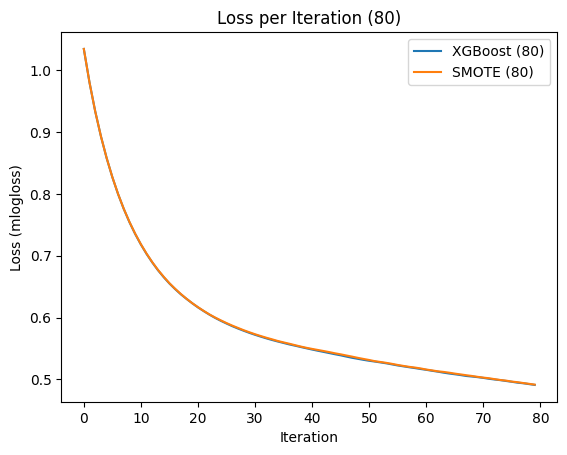

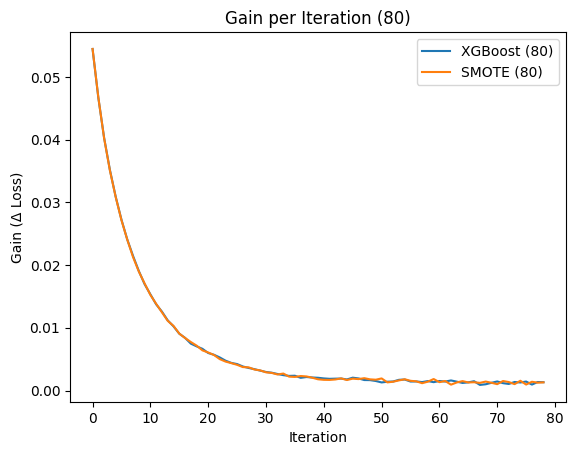

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET + FIX LEAKAGE
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

X = df.drop(columns=['target', 'purchase', 'avg_session_time'])
y = df['target'].astype(int)

# ===============================
# 4. SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# FUNCTION EVALUASI
# ===============================
def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")

    print("\nAccuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-score :", f1_score(y_true, y_pred, average='macro'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# =========================================================
# MODEL 1: XGBOOST (ITERASI = 80)
# =========================================================
model_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=80,   # 🔥 DIUBAH
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

model_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

# LOSS & GAIN
evals_result_base = model_base.evals_result()
loss_base = evals_result_base['validation_0']['mlogloss'][:80]
gain_base = -np.diff(loss_base)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost (80) ===")
for i in range(len(loss_base)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f}")
    else:
        gain = loss_base[i-1] - loss_base[i]
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_base = model_base.predict(X_test)
evaluate("XGBoost (80 Iterations)", y_test, y_pred_base)

# =========================================================
# MODEL 2: XGBOOST + SMOTE (ITERASI = 80)
# =========================================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_smote = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=80,   # 🔥 DIUBAH
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

model_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_train_sm, y_train_sm)],
    verbose=False
)

evals_result_smote = model_smote.evals_result()
loss_smote = evals_result_smote['validation_0']['mlogloss'][:80]
gain_smote = -np.diff(loss_smote)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost + SMOTE (80) ===")
for i in range(len(loss_smote)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f}")
    else:
        gain = loss_smote[i-1] - loss_smote[i]
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_smote = model_smote.predict(X_test)
evaluate("XGBoost + SMOTE (80 Iterations)", y_test, y_pred_smote)

# =========================================================
# PLOT LOSS
# =========================================================
plt.figure()
plt.plot(loss_base, label="XGBoost (80)")
plt.plot(loss_smote, label="SMOTE (80)")
plt.xlabel("Iteration")
plt.ylabel("Loss (mlogloss)")
plt.title("Loss per Iteration (80)")
plt.legend()
plt.show()

# =========================================================
# PLOT GAIN
# =========================================================
plt.figure()
plt.plot(gain_base, label="XGBoost (80)")
plt.plot(gain_smote, label="SMOTE (80)")
plt.xlabel("Iteration")
plt.ylabel("Gain (Δ Loss)")
plt.title("Gain per Iteration (80)")
plt.legend()
plt.show()

**Menggunakan Dept = 2 untuk XGBoost dan XGBoost + SMOTE**


=== Iteration Log: XGBoost Depth-2 ===
Iter   1 | Loss: 1.038041
Iter   2 | Loss: 0.987424 | Gain: 0.050617
Iter   3 | Loss: 0.981076 | Gain: 0.006348
Iter   4 | Loss: 0.943556 | Gain: 0.037520
Iter   5 | Loss: 0.924059 | Gain: 0.019497
Iter   6 | Loss: 0.888775 | Gain: 0.035284
Iter   7 | Loss: 0.858000 | Gain: 0.030775
Iter   8 | Loss: 0.844159 | Gain: 0.013842
Iter   9 | Loss: 0.831513 | Gain: 0.012645
Iter  10 | Loss: 0.807250 | Gain: 0.024263
Iter  11 | Loss: 0.796861 | Gain: 0.010389
Iter  12 | Loss: 0.776727 | Gain: 0.020134
Iter  13 | Loss: 0.776432 | Gain: 0.000295
Iter  14 | Loss: 0.776177 | Gain: 0.000255
Iter  15 | Loss: 0.765168 | Gain: 0.011009
Iter  16 | Loss: 0.748561 | Gain: 0.016607
Iter  17 | Loss: 0.735631 | Gain: 0.012930
Iter  18 | Loss: 0.728449 | Gain: 0.007182
Iter  19 | Loss: 0.721768 | Gain: 0.006681
Iter  20 | Loss: 0.709696 | Gain: 0.012072
Iter  21 | Loss: 0.698984 | Gain: 0.010712
Iter  22 | Loss: 0.693977 | Gain: 0.005007
Iter  23 | Loss: 0.684720 | Gai

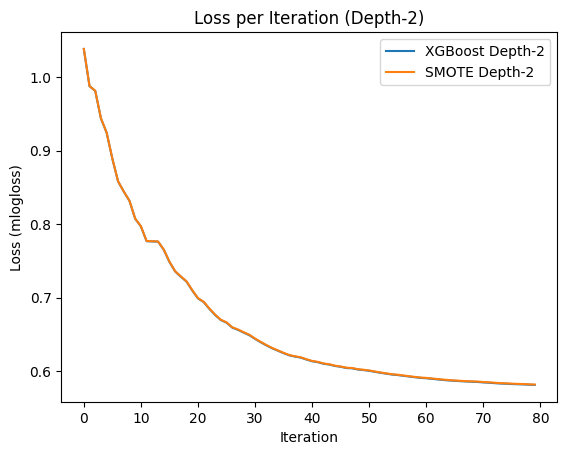

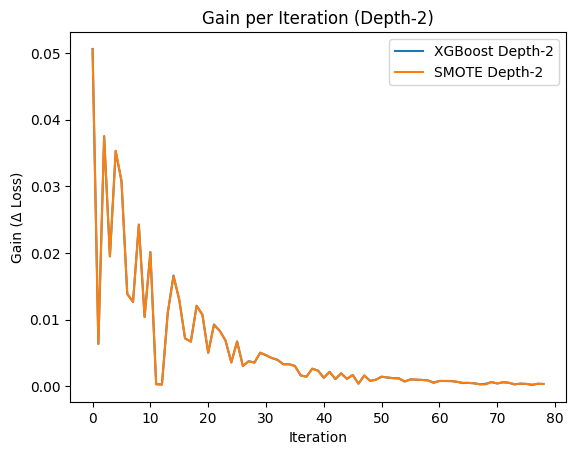

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
df = df.fillna(df.mean(numeric_only=True))

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

df = df.apply(pd.to_numeric)

# ===============================
# 3. TARGET + FIX LEAKAGE
# ===============================
df['target'] = pd.qcut(df['avg_session_time'], 3, labels=[0,1,2])

X = df.drop(columns=['target', 'purchase', 'avg_session_time'])
y = df['target'].astype(int)

# ===============================
# 4. SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# FUNCTION EVALUASI
# ===============================
def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")

    print("\nAccuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-score :", f1_score(y_true, y_pred, average='macro'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# =========================================================
# MODEL 1: XGBOOST (DEPTH-2)
# =========================================================
model_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=80,
    learning_rate=0.1,
    max_depth=2,                 # 🔥 DEPTH-2
    subsample=0.8,               # 🔥 tambahan
    colsample_bytree=0.8,        # 🔥 tambahan
    reg_lambda=1,                # 🔥 tambahan
    eval_metric='mlogloss',
    random_state=42
)

model_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

evals_result_base = model_base.evals_result()
loss_base = evals_result_base['validation_0']['mlogloss'][:80]
gain_base = -np.diff(loss_base)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost Depth-2 ===")
for i in range(len(loss_base)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f}")
    else:
        gain = loss_base[i-1] - loss_base[i]
        print(f"Iter {i+1:3d} | Loss: {loss_base[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_base = model_base.predict(X_test)
evaluate("XGBoost Depth-2", y_test, y_pred_base)

# =========================================================
# MODEL 2: XGBOOST + SMOTE (DEPTH-2)
# =========================================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_smote = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=80,
    learning_rate=0.1,
    max_depth=2,                 # 🔥 DEPTH-2
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=42
)

model_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_train_sm, y_train_sm)],
    verbose=False
)

evals_result_smote = model_smote.evals_result()
loss_smote = evals_result_smote['validation_0']['mlogloss'][:80]
gain_smote = -np.diff(loss_smote)

# ===============================
# ITERATION LOG
# ===============================
print("\n=== Iteration Log: XGBoost + SMOTE Depth-2 ===")
for i in range(len(loss_smote)):
    if i == 0:
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f}")
    else:
        gain = loss_smote[i-1] - loss_smote[i]
        print(f"Iter {i+1:3d} | Loss: {loss_smote[i]:.6f} | Gain: {gain:.6f}")

# ===============================
# EVALUATION
# ===============================
y_pred_smote = model_smote.predict(X_test)
evaluate("XGBoost + SMOTE Depth-2", y_test, y_pred_smote)

# =========================================================
# PLOT LOSS
# =========================================================
plt.figure()
plt.plot(loss_base, label="XGBoost Depth-2")
plt.plot(loss_smote, label="SMOTE Depth-2")
plt.xlabel("Iteration")
plt.ylabel("Loss (mlogloss)")
plt.title("Loss per Iteration (Depth-2)")
plt.legend()
plt.show()

# =========================================================
# PLOT GAIN
# =========================================================
plt.figure()
plt.plot(gain_base, label="XGBoost Depth-2")
plt.plot(gain_smote, label="SMOTE Depth-2")
plt.xlabel("Iteration")
plt.ylabel("Gain (Δ Loss)")
plt.title("Gain per Iteration (Depth-2)")
plt.legend()
plt.show()

**Modifikasi XGBoost dan XGBoost Klasik dan XGBoost**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# DATA LOSS (DARI HASIL ANDA)
# ===============================

loss_mod = [0.982297,0.926977,0.925716,0.924560,0.838312,0.837557,0.787855,0.773583,0.765198,0.760279,
0.757408,0.755570,0.754450,0.753679,0.753188,0.752783,0.752423,0.752058,0.749777,0.748482,
0.747697,0.747203,0.745227,0.744048,0.743294,0.742817,0.742541,0.742206,0.713291,0.698987,
0.691452,0.687242,0.685189,0.684049,0.683332,0.682891,0.670361,0.669005,0.668286,0.667967,
0.663892,0.661251,0.660635,0.658792,0.657452,0.656503,0.655777,0.655172,0.654249,0.653230,
0.652657,0.652290,0.638054,0.636474,0.635039,0.634089,0.632827,0.632075,0.630915,0.630203,
0.629535,0.628874,0.627836,0.627447,0.626741,0.626252,0.625954,0.625624,0.621963,0.619287,
0.617243,0.615657,0.614410,0.613314,0.612454,0.611773,0.611170,0.610729,0.610223,0.609915]

gain_mod = [3.865324,3.736723,3.628695,3.531530,3.415727,3.282043,3.243631,3.170083,3.221590,3.171562,
3.214057,3.376393,3.418935,3.344500,3.197313,3.052101,3.041462,2.958955,2.887302,2.997734,
2.990826,2.896110,2.752631,2.839006,2.877044,2.836127,2.737925,2.729410,2.713610,2.808885,
2.916389,2.860218,2.720197,2.849427,2.852249,2.776037,2.727691,2.828884,2.867424,2.876104,
2.840115,3.090403,3.346198,3.248585,3.357127,3.396458,3.374813,3.359695,3.363421,3.263942,
3.180422,3.024739,2.919870,2.956771,3.056260,3.125404,3.167286,3.170513,3.195836,3.178217,
3.186099,3.158923,3.130768,3.105975,3.110347,3.016246,2.930845,2.832559,2.823264,2.834131,
2.933290,3.065519,3.159391,3.254243,3.286653,3.287079,3.235515,3.140851,3.065389,2.908821]

loss_base = [1.034205,0.979772,0.933126,0.892876,0.857726,0.826839,0.799622,0.775549,0.754094,0.735042,
0.718091,0.702759,0.689024,0.676451,0.665272,0.655046,0.645988,0.637602,0.630132,0.623097,
0.616450,0.610473,0.604778,0.599508,0.594751,0.590349,0.586133,0.582304,0.578711,0.575311,
0.572143,0.569188,0.566353,0.563720,0.561275,0.558947,0.556591,0.554570,0.552422,0.550345,
0.548315,0.546388,0.544525,0.542635,0.540729,0.538968,0.536923,0.534998,0.533330,0.531674,
0.530162,0.528875,0.527476,0.526038,0.524332,0.522582,0.521152,0.519708,0.518367,0.516864,
0.515535,0.514019,0.512592,0.510988,0.509576,0.508372,0.507071,0.505590,0.504700,0.503708,
0.502480,0.501037,0.499867,0.498823,0.497466,0.496188,0.494758,0.493817,0.492465,0.491142]

loss_smote = [1.034172,0.979727,0.933037,0.892842,0.857775,0.826937,0.799798,0.775744,0.754475,0.735517,
0.718456,0.703218,0.689402,0.676942,0.665833,0.655540,0.646470,0.638099,0.630371,0.623217,
0.616820,0.610761,0.605102,0.600097,0.595486,0.591123,0.587029,0.583295,0.579604,0.576258,
0.573052,0.570154,0.567351,0.564798,0.562094,0.559884,0.557719,0.555411,0.553170,0.551132,
0.549344,0.547641,0.545951,0.544190,0.542262,0.540589,0.538701,0.536881,0.534916,0.533138,
0.531417,0.529492,0.528198,0.526795,0.525183,0.523394,0.521848,0.520388,0.519221,0.517814,
0.515985,0.514657,0.513140,0.512207,0.510924,0.509427,0.508144,0.506825,0.505609,0.504182,
0.502949,0.501938,0.500425,0.499078,0.498065,0.496510,0.495561,0.494168,0.492920,0.491621]

# ===============================
# HITUNG GAIN (Δ LOSS)
# ===============================
gain_base = [0] + list(np.diff(loss_base) * -1)
gain_smote = [0] + list(np.diff(loss_smote) * -1)

# ===============================
# PLOT LOSS
# ===============================
plt.figure()
plt.plot(loss_mod, label="Modified XGBoost")
plt.plot(loss_base, label="XGBoost")
plt.plot(loss_smote, label="XGBoost + SMOTE")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Comparison Across Models")
plt.legend()
plt.savefig("loss_comparison.png")
plt.close()

# ===============================
# PLOT GAIN (3 MODEL)
# ===============================
plt.figure()
plt.plot(gain_mod, label="Modified XGBoost")
plt.plot(gain_base, label="XGBoost")
plt.plot(gain_smote, label="XGBoost + SMOTE")
plt.xlabel("Iteration")
plt.ylabel("Gain")
plt.title("Gain Comparison Across Models")
plt.legend()
plt.savefig("gain_comparison.png")
plt.close()

print("✔ Semua grafik berhasil disimpan:")
print("- loss_comparison.png")
print("- gain_comparison.png")

✔ Semua grafik berhasil disimpan:
- loss_comparison.png
- gain_comparison.png


**Grafik 3 model pada laporan klasifikasi**